In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
sns.set()
%config InlineBackend.figure_format = 'svg'

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [ ]:
data_url=DATA_URL+ "telecom_churn.csv"
df = pd.read_csv(data_url)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
selected_features = ["Total day minutes", "Total intl calls"]

array([[<Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>]], dtype=object)

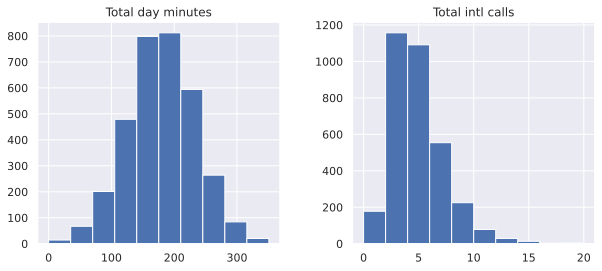

In [ ]:
df[selected_features].hist(figsize=(10, 4))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

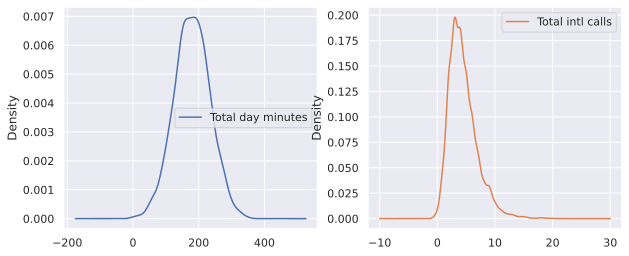

In [ ]:
df[selected_features].plot(
kind="density",
subplots=True,
layout=(1, 2),
sharex=False,
figsize=(10, 4)
)

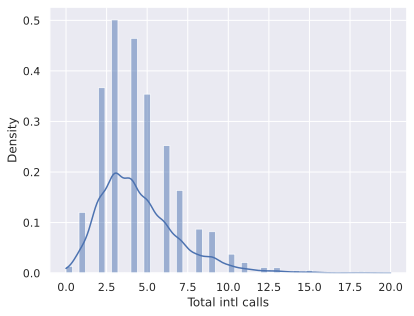

In [ ]:
sns.histplot(df["Total intl calls"], kde=True, stat="density");

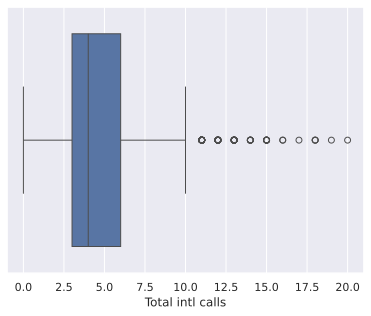

In [ ]:
sns.boxplot(x="Total intl calls", data=df);

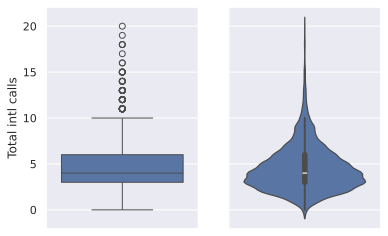

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
sns.violinplot(data=df["Total intl calls"], ax=axes[1]);

In [ ]:
df[selected_features].describe()

,Total day minutes,Total intl calls
count,3333.000000,3333.000000
mean,179.775098,4.479448
std,54.467389,2.461214
min,0.000000,0.000000
25%,143.700000,3.000000
50%,179.400000,4.000000
75%,216.400000,6.000000
max,350.800000,20.000000


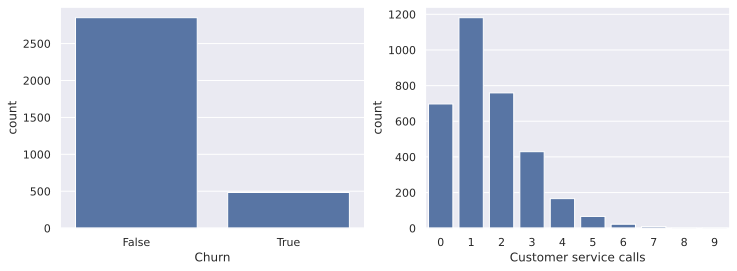

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.countplot(x="Churn", data=df, ax=axes[0])
sns.countplot(x="Customer service calls", data=df, ax=axes[1]);


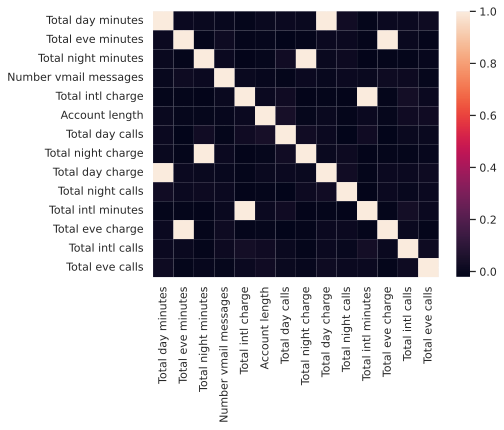

In [ ]:
numerical = list(
set(df.columns)
- set(
[
"State",
"International plan",
"Voice mail plan",
"Area code",
"Churn",
"Customer service calls",
]
)
)

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);

In [ ]:
numerical = list(
set(numerical)
- set(
[
"Total day charge",
"Total eve charge",
"Total night charge",
"Total intl charge",
]
)
)

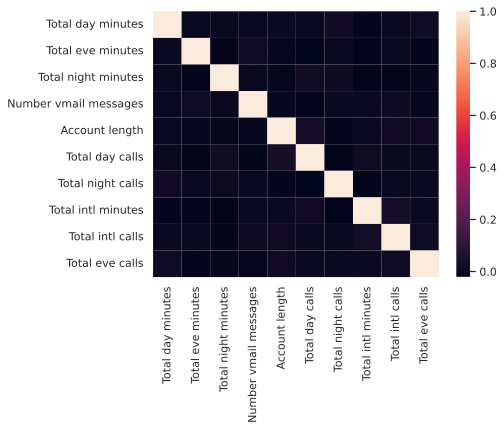

In [ ]:
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);

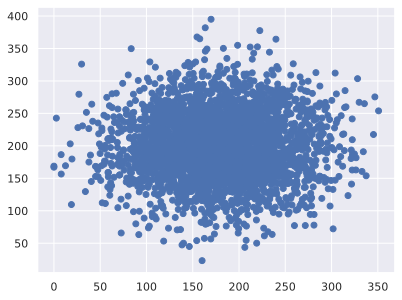

In [ ]:
plt.scatter(df["Total day minutes"], df["Total night minutes"]);

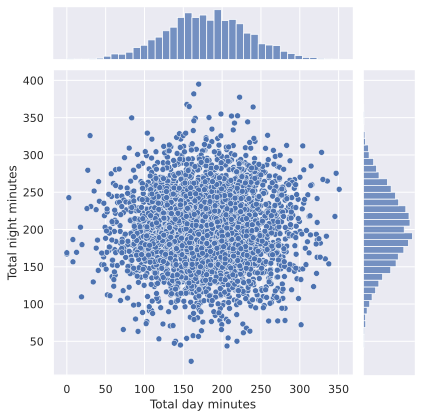

In [ ]:
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter");

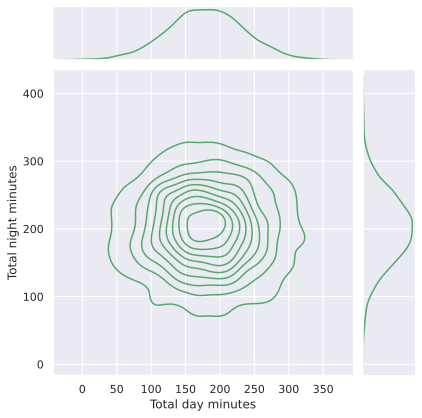

In [ ]:
sns.jointplot(
x="Total day minutes", y="Total night minutes", data=df, kind="kde", color="g"
);

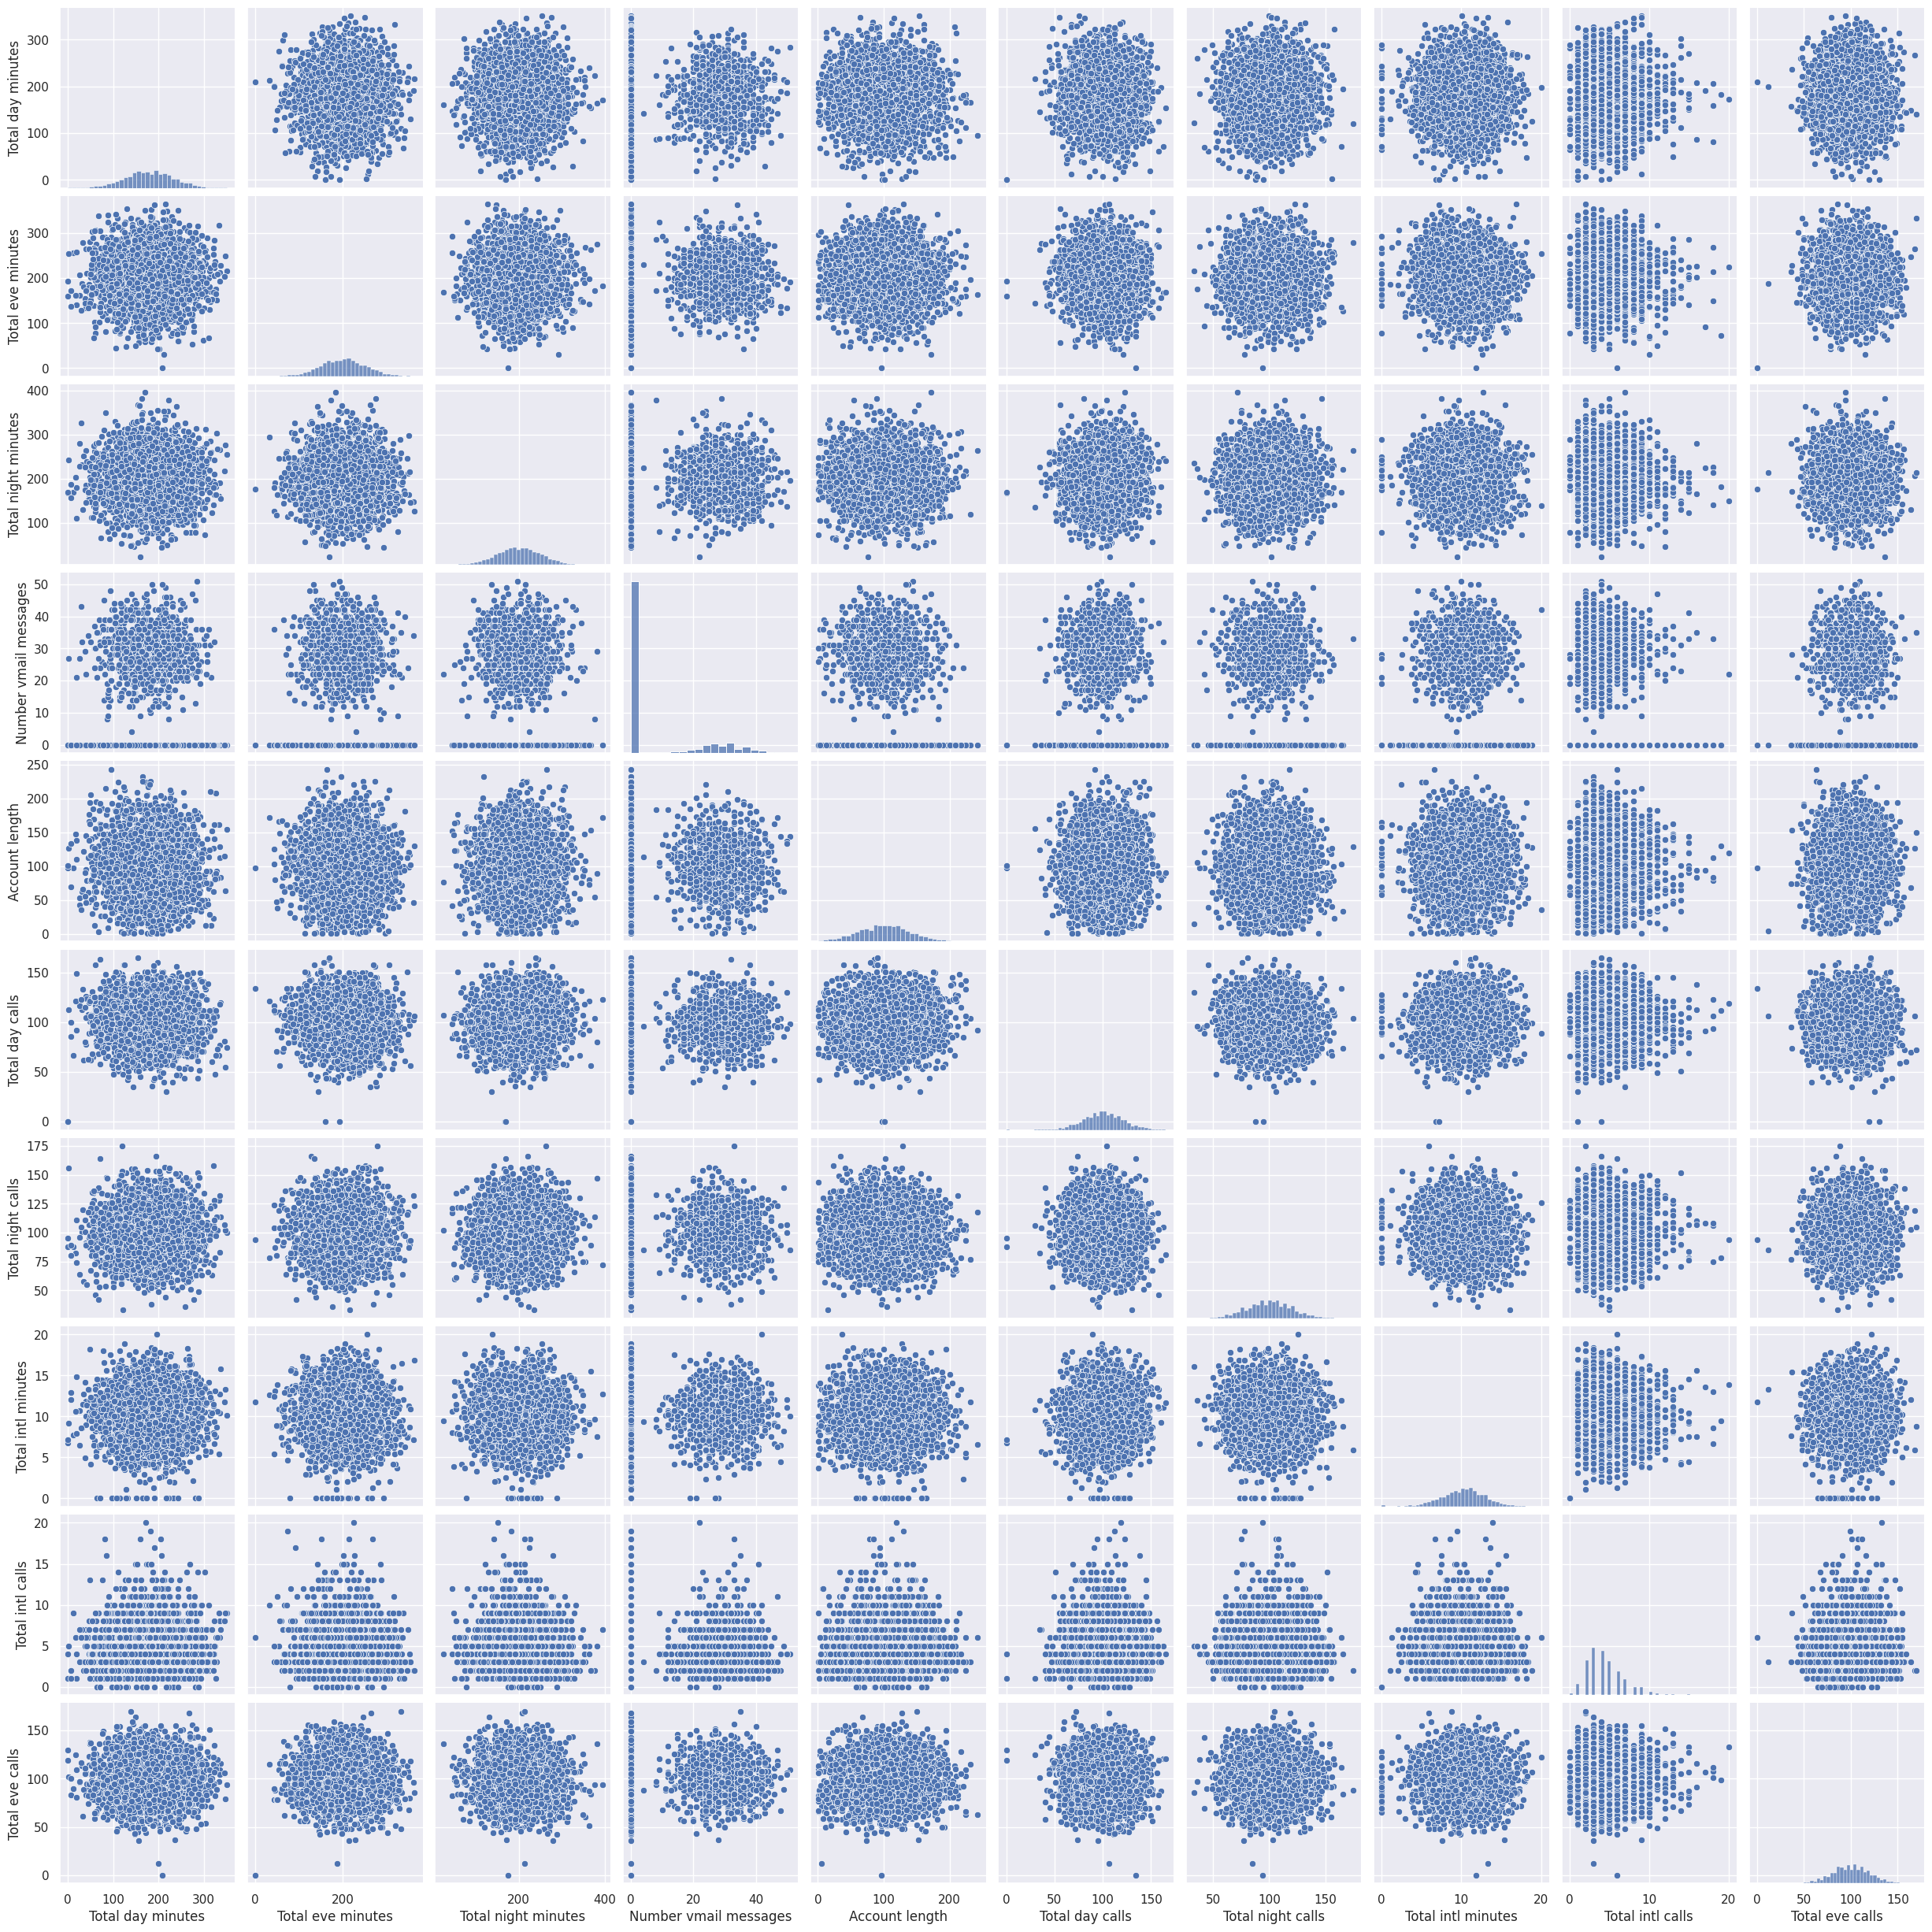

In [ ]:

%config InlineBackend.figure_format = 'png'
sns.pairplot(df[numerical]);

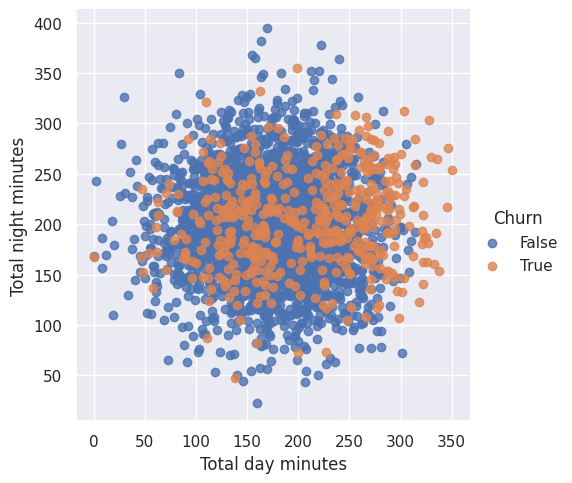

In [ ]:
sns.lmplot(
x="Total day minutes", y="Total night minutes", data=df, hue="Churn", fit_reg=False
);

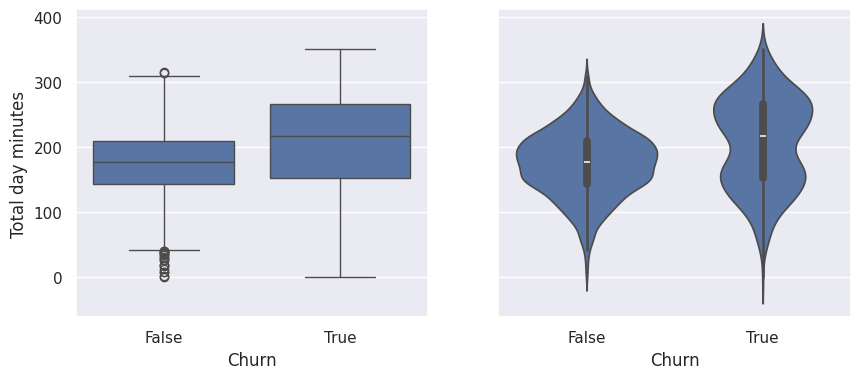

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.boxplot(x="Churn", y="Total day minutes", data=df, ax=axes[0])
sns.violinplot(x="Churn", y="Total day minutes", data=df, ax=axes[1]);

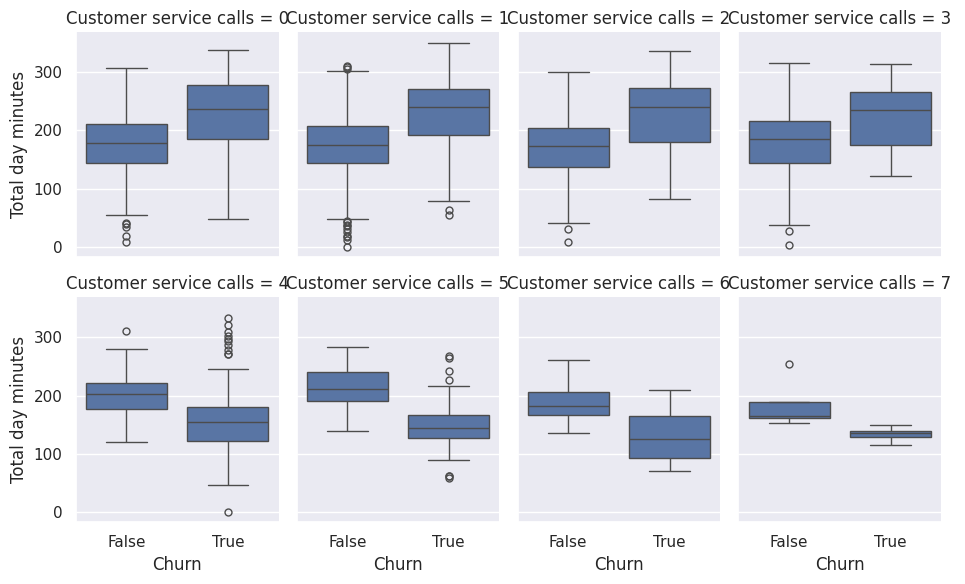

In [ ]:
sns.catplot(
x="Churn",
y="Total day minutes",
col="Customer service calls",
data=df[df["Customer service calls"] < 8],
kind="box",
col_wrap=4,
height=3,
aspect=0.8,
);

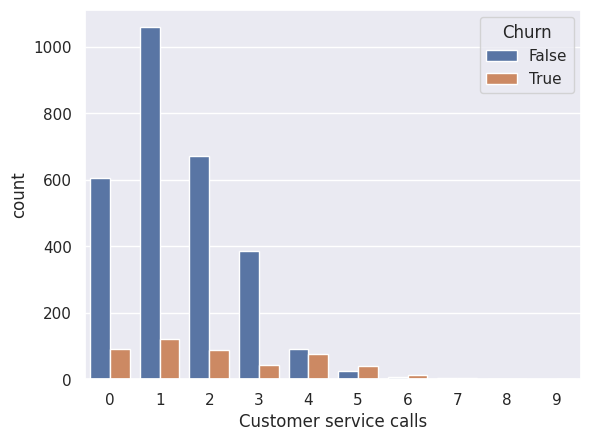

In [ ]:
sns.countplot(x="Customer service calls", hue="Churn", data=df);

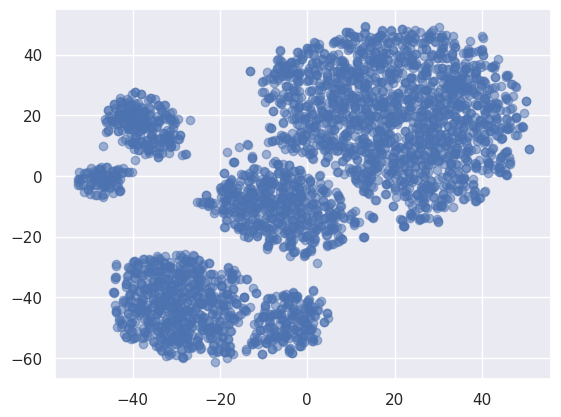

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
X = df.drop(["Churn", "State"], axis=1)
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0})
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0})
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(random_state=17)
tsne_repr = tsne.fit_transform(X_scaled)
plt.scatter(tsne_repr[:, 0], tsne_repr[:, 1], alpha=0.5);

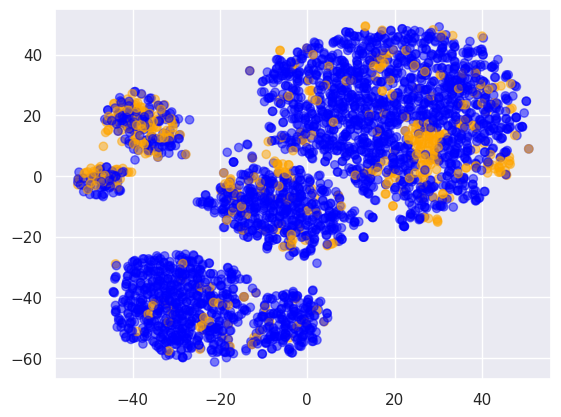

In [ ]:
plt.scatter(
tsne_repr[:, 0],
tsne_repr[:, 1],
c=df["Churn"].map({False: "blue", True: "orange"}),
alpha=0.5,
);